# 7단계 · MA 정렬 + ADX 시장국면 통합 전략

## 개요
**MA 정렬 + ADX 조합** — 기관·퀀트에서 가장 널리 쓰이는 시장 국면 판별 방법입니다.

| 국면 | 판별 조건 | 적용 전략 | 매수 방식 | 매도 방식 |
|------|----------|----------|----------|----------|
| **상승 추세장 (UPTREND)** | MA20 > MA60 > MA120 AND ADX > 25 | 추세 추종 (골든크로스) | 골든크로스 발생 시 100% 진입 | 데드크로스 또는 DOWNTREND 전환 시 청산 |
| **하락 추세장 (DOWNTREND)** | MA20 < MA60 < MA120 AND ADX > 25 | 전량 청산 → 현금 보유 | 매수 없음 | 전량 청산 (size=0) |
| **횡보장 (SIDEWAYS)** | ADX < 20 | 볼린저 밴드 (평균 회귀) | BB 하단 터치 시 50% 진입 | BB 상단 터치 또는 DOWNTREND 전환 시 청산 |
| **전환 구간 (TRANSITION)** | 위 3가지 조건 미해당 | 신규 진입 차단, 기존 포지션 유지 | 매수 없음 | 별도 청산 없음 (NaN 유지) |

### 판별 우선순위
1. ADX < 20 → SIDEWAYS
2. MA20 > MA60 > MA120 AND ADX > 25 → UPTREND
3. MA20 < MA60 < MA120 AND ADX > 25 → DOWNTREND
4. 그 외 → TRANSITION (신규 진입만 차단, 기존 포지션 유지)

### 포지션 크기 조절
```
UPTREND   → 골든크로스 진입 → 100% (추세 완전 확인)
SIDEWAYS  → 볼린저밴드 진입 →  50% (횡보, 방향 불명)
DOWNTREND → 전량 청산       →   0% (현금 보유)
TRANSITION→ NaN 유지        →  기존 포지션 그대로 (신규 진입 차단만)
```

### 파라미터 기본값
- MA: 20일 / 60일 / 120일
- ADX 추세 임계값: 25
- ADX 횡보 임계값: 20
- ADX 기간: 14일

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드: 삼성전자 (005930.KS) 2019~2024 ──────────────────────────────
TICKER = '005930.KS'
START  = '2019-01-01'
END    = '2024-12-31'

df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

close  = df['Close'].squeeze()
high   = df['High'].squeeze()
low    = df['Low'].squeeze()
volume = df['Volume'].squeeze()

print(f'종목  : 삼성전자 ({TICKER})')
print(f'기간  : {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'거래일: {len(close)}일')
print(f'시작가: {close.iloc[0]:,.0f}원  /  종가: {close.iloc[-1]:,.0f}원')

종목  : 삼성전자 (005930.KS)
기간  : 2019-01-02 ~ 2024-12-30
거래일: 1475일
시작가: 32,297원  /  종가: 51,969원


---
## 1단계 · MA 3중 구조 분석 (20 / 60 / 120)

### 정렬 패턴 해석표

| 패턴 | 의미 | 대응 |
|------|------|------|
| MA20 > MA60 > MA120 | 단·중·장기 모두 상승 → **완전 상승 정렬** | 추세 추종 전략 |
| MA20 < MA60 < MA120 | 단·중·장기 모두 하락 → **완전 하락 정렬** | 현금 보유 |
| MA20 ≈ MA60 교차 반복 | 방향성 없음 → **횡보** | 평균 회귀 전략 |
| MA20 < MA60 > MA120 | 중기 꺾임, 장기 유효 → **조정 구간** | 관망/부분 청산 |

> **MA60(분기선)이 핵심**: 실적 발표 주기(분기)와 일치해 기관 포지션 기준선으로 활용됩니다.

=== MA 정렬 상태 분포 ===
  상승 정렬 (Bull) :  578일 (39.2%)
  하락 정렬 (Bear) :  360일 (24.4%)
  혼재 (횡보/조정) :  537일 (36.4%)


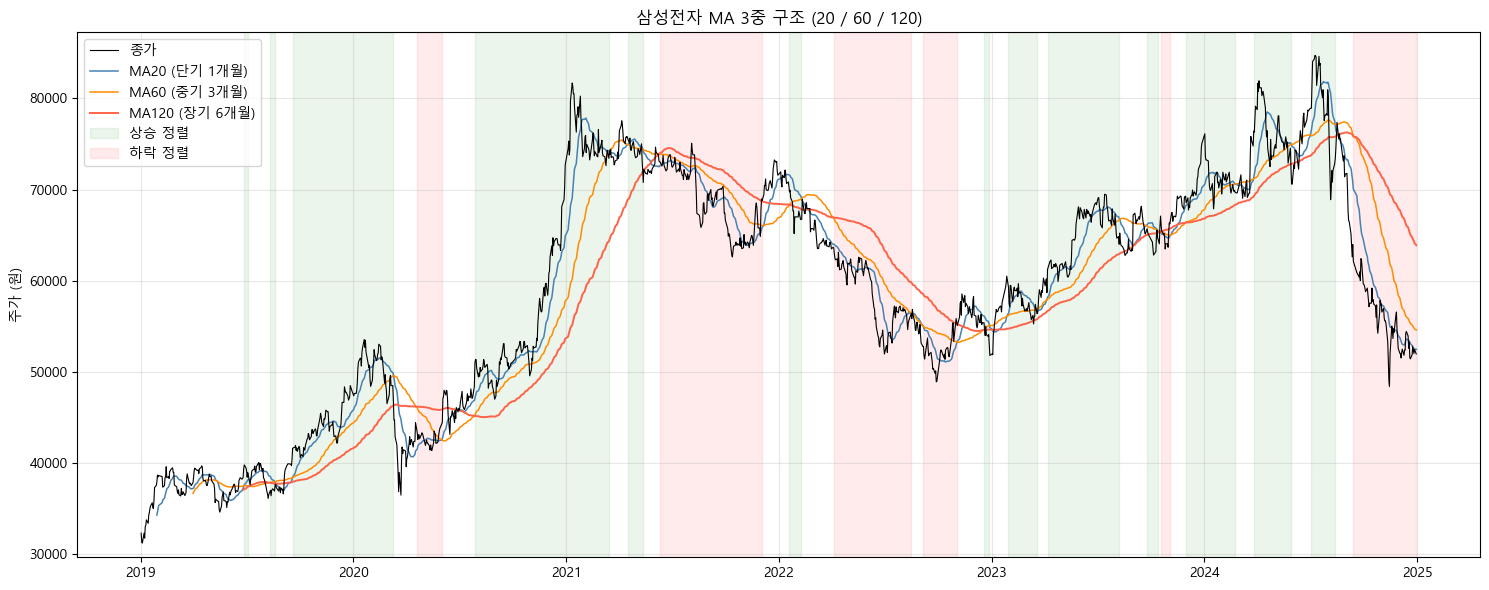

In [2]:
# ── MA 계산 ──────────────────────────────────────────────────────────────────
ma20  = close.rolling(20).mean()
ma60  = close.rolling(60).mean()
ma120 = close.rolling(120).mean()

bull_align = (ma20 > ma60) & (ma60 > ma120)
bear_align = (ma20 < ma60) & (ma60 < ma120)
mixed      = ~bull_align & ~bear_align

print('=== MA 정렬 상태 분포 ===')
total = len(close)
print(f'  상승 정렬 (Bull) : {bull_align.sum():4d}일 ({bull_align.mean():.1%})')
print(f'  하락 정렬 (Bear) : {bear_align.sum():4d}일 ({bear_align.mean():.1%})')
print(f'  혼재 (횡보/조정) : {mixed.sum():4d}일 ({mixed.mean():.1%})')

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(close, color='black',     linewidth=0.8, label='종가', zorder=5)
ax.plot(ma20,  color='steelblue', linewidth=1.1, label='MA20 (단기 1개월)')
ax.plot(ma60,  color='darkorange',linewidth=1.1, label='MA60 (중기 3개월)')
ax.plot(ma120, color='tomato',    linewidth=1.4, label='MA120 (장기 6개월)')

ymin, ymax = close.min() * 0.95, close.max() * 1.03
ax.fill_between(close.index, ymin, ymax, where=bull_align,
                color='green', alpha=0.08, label='상승 정렬')
ax.fill_between(close.index, ymin, ymax, where=bear_align,
                color='red',   alpha=0.08, label='하락 정렬')

ax.set_title('삼성전자 MA 3중 구조 (20 / 60 / 120)')
ax.set_ylabel('주가 (원)')
ax.set_ylim(ymin, ymax)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2단계 · ADX 추세 강도 분석

MA 정렬로 방향을 확인했다면, ADX로 **그 추세에 실제로 힘이 있는지** 검증합니다.

```
ADX < 20       → 횡보 (추세 없음)
ADX 20 ~ 25    → 과도기 (신호 신뢰도 낮음)
ADX 25 ~ 40    → 중간 추세 ← 기관 진입 구간
ADX > 40       → 강한 추세 (추격 매수 주의, 이미 많이 오름)
```

> **포인트**: MA 정렬 + ADX > 25를 **동시에** 만족할 때만 추세장으로 확정해야 휩쏘(가짜 신호)를 걸러낼 수 있습니다.

=== ADX 통계 ===
  평균 ADX         : 22.9
  ADX < 20 (횡보)   : 686일 (46.5%)
  ADX 20~25 (과도기): 271일
  ADX > 25 (추세)   : 505일 (34.2%)
  ADX > 40 (강추세) : 93일 (6.3%)


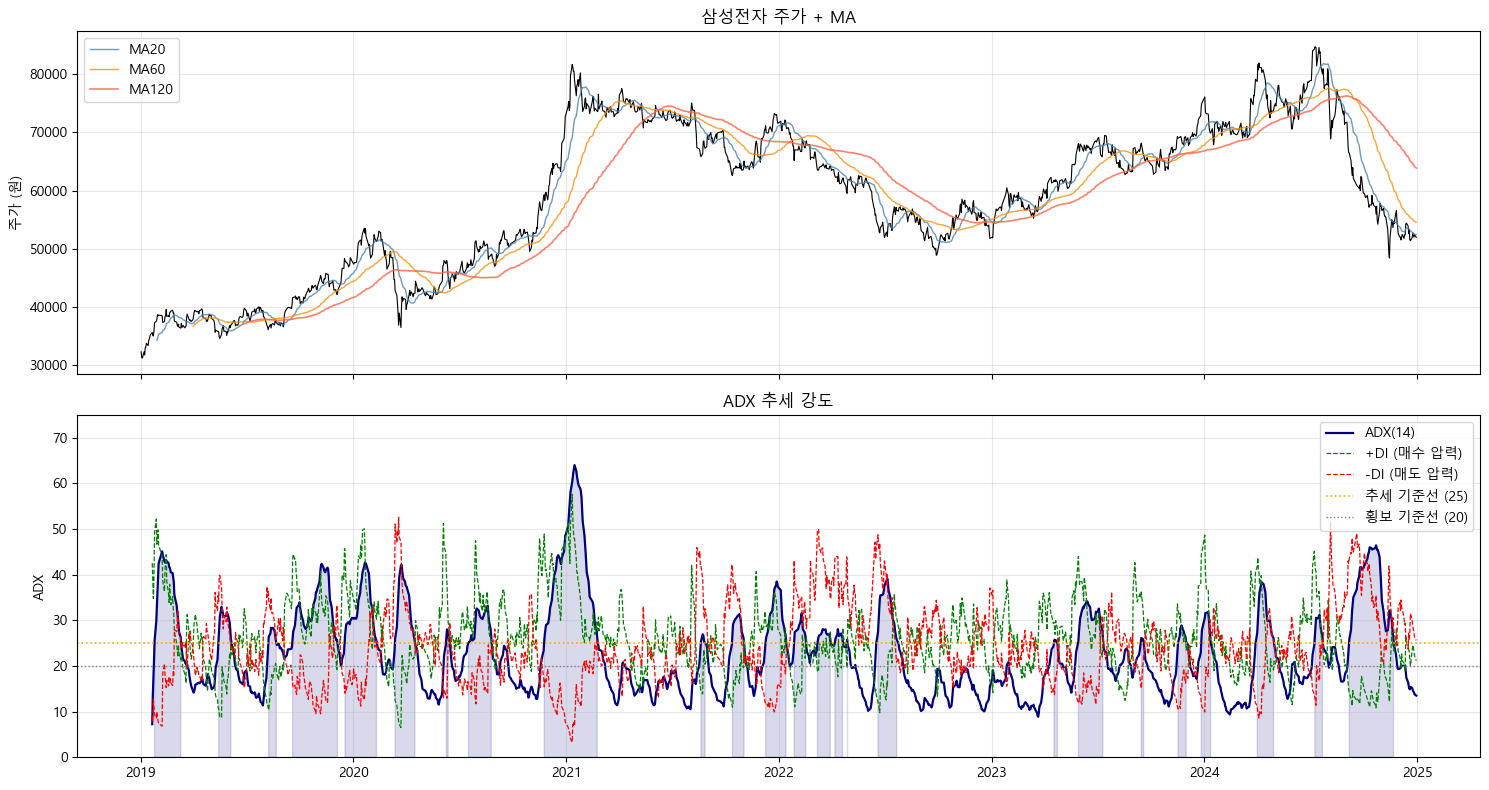

In [3]:
from vbt_backtest.strategies.indicators.adx_strategy import calc_adx

adx_df   = calc_adx(high, low, close, window=14)
adx      = adx_df['ADX']
plus_di  = adx_df['plus_di']
minus_di = adx_df['minus_di']

print('=== ADX 통계 ===')
print(f'  평균 ADX         : {adx.mean():.1f}')
print(f'  ADX < 20 (횡보)   : {(adx < 20).sum()}일 ({(adx < 20).mean():.1%})')
print(f'  ADX 20~25 (과도기): {((adx >= 20) & (adx < 25)).sum()}일')
print(f'  ADX > 25 (추세)   : {(adx >= 25).sum()}일 ({(adx >= 25).mean():.1%})')
print(f'  ADX > 40 (강추세) : {(adx > 40).sum()}일 ({(adx > 40).mean():.1%})')

# ── ADX 시각화 ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(close, color='black',      linewidth=0.8)
ax1.plot(ma20,  color='steelblue',  linewidth=1.0, alpha=0.8, label='MA20')
ax1.plot(ma60,  color='darkorange', linewidth=1.0, alpha=0.8, label='MA60')
ax1.plot(ma120, color='tomato',     linewidth=1.2, alpha=0.8, label='MA120')
ax1.set_title('삼성전자 주가 + MA')
ax1.set_ylabel('주가 (원)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(adx,      color='navy',   linewidth=1.6, label='ADX(14)')
ax2.plot(plus_di,  color='green',  linewidth=0.9, linestyle='--', label='+DI (매수 압력)')
ax2.plot(minus_di, color='red',    linewidth=0.9, linestyle='--', label='-DI (매도 압력)')
ax2.axhline(25, color='orange', linewidth=1.2, linestyle=':', label='추세 기준선 (25)')
ax2.axhline(20, color='gray',   linewidth=1.0, linestyle=':', label='횡보 기준선 (20)')
ax2.fill_between(adx.index, 0, adx, where=(adx >= 25), alpha=0.15, color='navy')
ax2.set_title('ADX 추세 강도')
ax2.set_ylabel('ADX')
ax2.set_ylim(0, 75)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3단계 · 시장 국면 자동 판별

MA 정렬 + ADX를 결합해 **4가지 국면**으로 분류합니다.

| 국면 | 판별 조건 | 색상 |
|------|---------|------|
| 상승 추세 (UPTREND) | MA20 > MA60 > MA120 AND ADX > 25 | 초록 |
| 하락 추세 (DOWNTREND) | MA20 < MA60 < MA120 AND ADX > 25 | 빨강 |
| 횡보장 (SIDEWAYS) | ADX < 20 | 회색 |
| 전환 구간 (TRANSITION) | 위 3가지 조건 미해당 | 노랑 |

### 판별 우선순위
1. ADX < 20 → **SIDEWAYS** (먼저 확인)
2. MA20 > MA60 > MA120 AND ADX > 25 → **UPTREND**
3. MA20 < MA60 < MA120 AND ADX > 25 → **DOWNTREND**
4. 그 외 → **TRANSITION**

In [4]:
from vbt_backtest.strategies.combined.ma_regime_strategy import (
    calc_regime, make_signals, run_backtest, REGIME_COLORS
)

# ── 국면 판별 ─────────────────────────────────────────────────────────────────
regime, masks, adx_df = calc_regime(close, high, low)

UPTREND    = masks["UPTREND"]
DOWNTREND  = masks["DOWNTREND"]
SIDEWAYS   = masks["SIDEWAYS"]
TRANSITION = masks["TRANSITION"]
ma20       = masks["ma_s"]
ma60       = masks["ma_m"]
ma120      = masks["ma_l"]
adx        = masks["adx"]

print('=== 시장 국면 분포 (삼성전자 2019~2024) ===')
counts = regime.value_counts()
for name, cnt in counts.items():
    print(f'  {name:12s}: {cnt:4d}일 ({cnt/len(regime):.1%})')

=== 시장 국면 분포 (삼성전자 2019~2024) ===
  SIDEWAYS    :  686일 (46.5%)
  TRANSITION  :  431일 (29.2%)
  UPTREND     :  257일 (17.4%)
  DOWNTREND   :  101일 (6.8%)


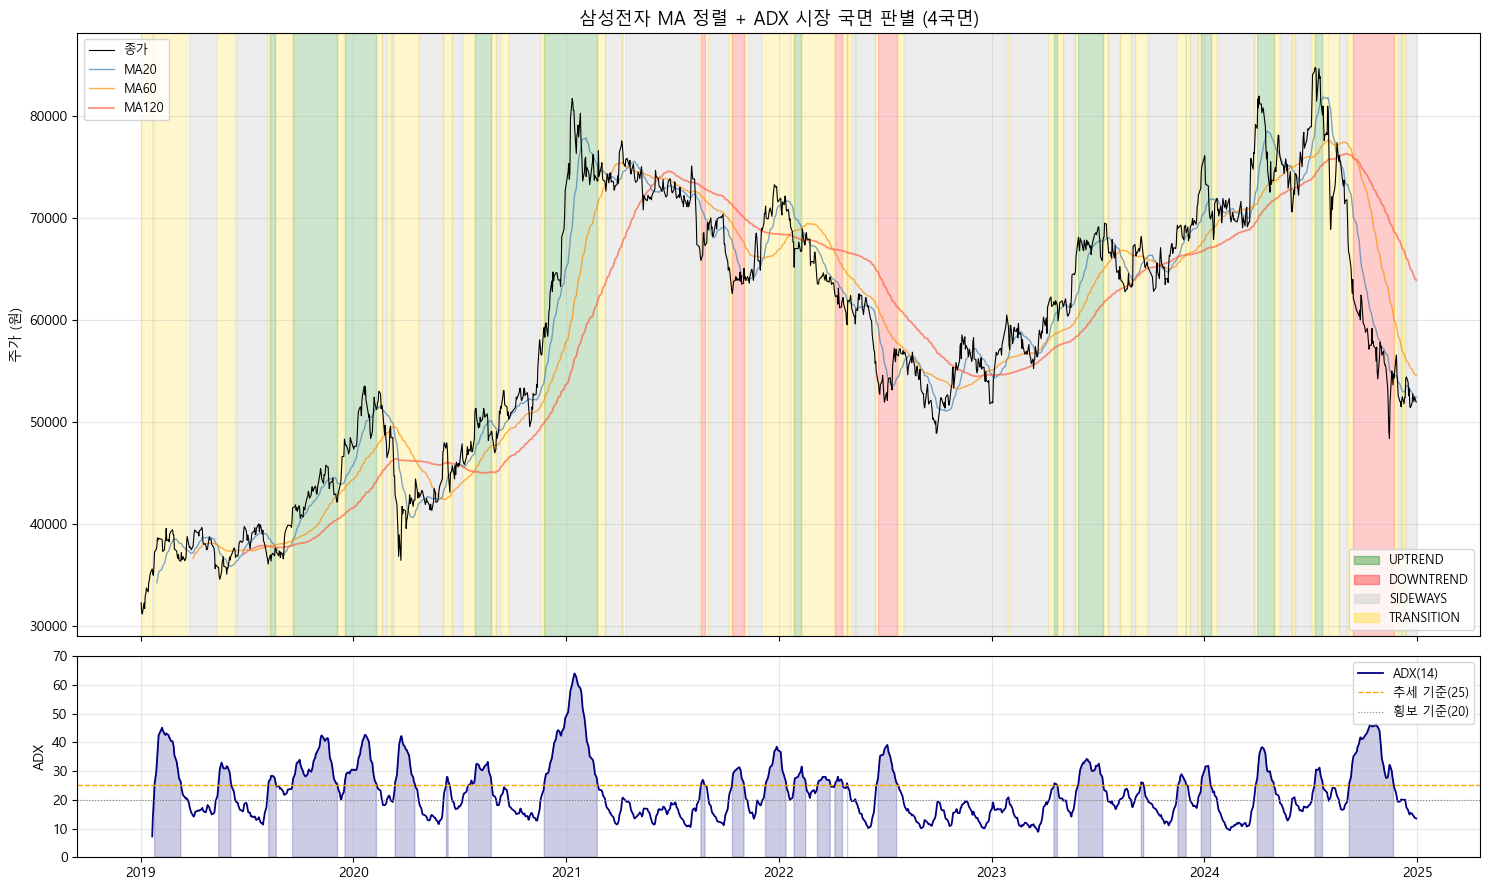

In [5]:
# ── 국면별 가격 차트 시각화 ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ymin, ymax = close.min() * 0.93, close.max() * 1.04
patches = []
for name, (color, alpha) in REGIME_COLORS.items():
    mask = regime == name
    ax1.fill_between(close.index, ymin, ymax, where=mask, color=color, alpha=alpha)
    patches.append(mpatches.Patch(color=color, alpha=alpha + 0.15, label=name))

ax1.plot(close, color='black',      linewidth=0.8, zorder=5, label='종가')
ax1.plot(ma20,  color='steelblue',  linewidth=1.0, alpha=0.7, label='MA20')
ax1.plot(ma60,  color='darkorange', linewidth=1.0, alpha=0.7, label='MA60')
ax1.plot(ma120, color='tomato',     linewidth=1.3, alpha=0.7, label='MA120')

ax1.set_title('삼성전자 MA 정렬 + ADX 시장 국면 판별 (4국면)', fontsize=13)
ax1.set_ylabel('주가 (원)')
ax1.set_ylim(ymin, ymax)
line_leg = ax1.legend(loc='upper left', fontsize=9)
ax1.add_artist(line_leg)
ax1.legend(handles=patches, loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# 하단: ADX 패널
ax2.plot(adx, color='navy', linewidth=1.3, label='ADX(14)')
ax2.axhline(25, color='orange', linewidth=1.0, linestyle='--', label='추세 기준(25)')
ax2.axhline(20, color='gray',   linewidth=0.8, linestyle=':', label='횡보 기준(20)')
ax2.fill_between(adx.index, 0, adx, where=(adx >= 25), alpha=0.2, color='navy')
ax2.set_ylabel('ADX')
ax2.set_ylim(0, 70)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4단계 · 국면별 전략 적용

### 4국면 매수/매도 전략 매핑

| 국면 | 적용 전략 | 매수 방식 | 매수 대상 | 매도 방식 | 매도 대상 |
|------|----------|----------|----------|----------|----------|
| **UPTREND** | 추세 추종 (골든크로스) | 신규 매수 | 골든크로스 발생 | 데드크로스 또는 DOWNTREND 전환 시 청산 | 보유 포지션 |
| **DOWNTREND** | 전량 청산 → 현금 보유 | 매수 없음 | — | 전량 청산 (size=0) | 보유 종목 전체 |
| **SIDEWAYS** | 볼린저 밴드 (평균 회귀) | 하단 터치 시 매수 | BB 하단 접촉 | BB 상단 터치 또는 DOWNTREND 전환 시 청산 | 보유 포지션 |
| **TRANSITION** | 신규 진입 차단, 기존 포지션 유지 | 매수 없음 | — | 별도 청산 없음 (NaN 유지) | — |

### TRANSITION 처리 방식

```
TRANSITION → 신규 진입 차단, 기존 포지션 유지
  └ 이유: MA120 후행성으로 인한 불필요한 조기 청산 방지
  └ 효과: 포지션이 전략 신호(데드크로스·DOWNTREND 전환)로만 청산됨
```

### 매도 방식 상세

| 매도 방식 | 발동 조건 | 목적 |
|----------|----------|------|
| **데드크로스 청산** | UPTREND 중 MA20이 MA60을 하향 돌파 | 추세 약화 시 포지션 정리 |
| **BB 상단 청산** | SIDEWAYS 중 볼린저밴드 상단 터치 | 평균 회귀 목표 도달 시 청산 |
| **전량 청산 (Sell All)** | 국면이 DOWNTREND 전환 시 | 시장 전체 리스크 회피, MDD 제어 |

In [6]:
# ── 국면별 전략 신호 생성 (모듈 활용) ───────────────────────────────────────
entries, exits, size_series, detail = make_signals(close, high, low)

gc_entries     = detail["gc_entries"]
bb_entries     = detail["bb_entries"]
gc_entries_raw = detail["gc_entries_raw"]
bb_entries_raw = detail["bb_entries_raw"]

print('=== 국면 필터 적용 후 신호 수 ===')
print(f'  골든크로스 (UPTREND):  {gc_entries_raw.sum():3d}회 → 필터 후 {gc_entries.sum():3d}회')
print(f'  볼린저밴드 (SIDEWAYS): {bb_entries_raw.sum():3d}회 → 필터 후 {bb_entries.sum():3d}회')
print(f'  전체 매수 신호: {entries.sum()}회')
print(f'\n  DOWNTREND 구간: {DOWNTREND.sum()}일 → 전량 청산')
print(f'  TRANSITION 구간: {TRANSITION.sum()}일 → 신규 진입 차단, 기존 포지션 유지')

print('\n=== 포지션 크기 분포 ===')
print(f'  100% 진입 (UPTREND  골든크로스): {(size_series == 1.0).sum()}회')
print(f'   50% 진입 (SIDEWAYS 볼린저밴드): {(size_series == 0.5).sum()}회')
print(f'    0% 청산 (DOWNTREND만):         {(size_series == 0.0).sum()}일')
print(f'  NaN 유지 (TRANSITION 포함):      {size_series.isna().sum()}일 ← 기존 포지션 유지')

=== 국면 필터 적용 후 신호 수 ===
  골든크로스 (UPTREND):   14회 → 필터 후   1회
  볼린저밴드 (SIDEWAYS):  34회 → 필터 후   8회
  전체 매수 신호: 9회

  DOWNTREND 구간: 101일 → 전량 청산
  TRANSITION 구간: 431일 → 신규 진입 차단, 기존 포지션 유지

=== 포지션 크기 분포 ===
  100% 진입 (UPTREND  골든크로스): 1회
   50% 진입 (SIDEWAYS 볼린저밴드): 8회
    0% 청산 (DOWNTREND만):         101일
  NaN 유지 (TRANSITION 포함):      1365일 ← 기존 포지션 유지


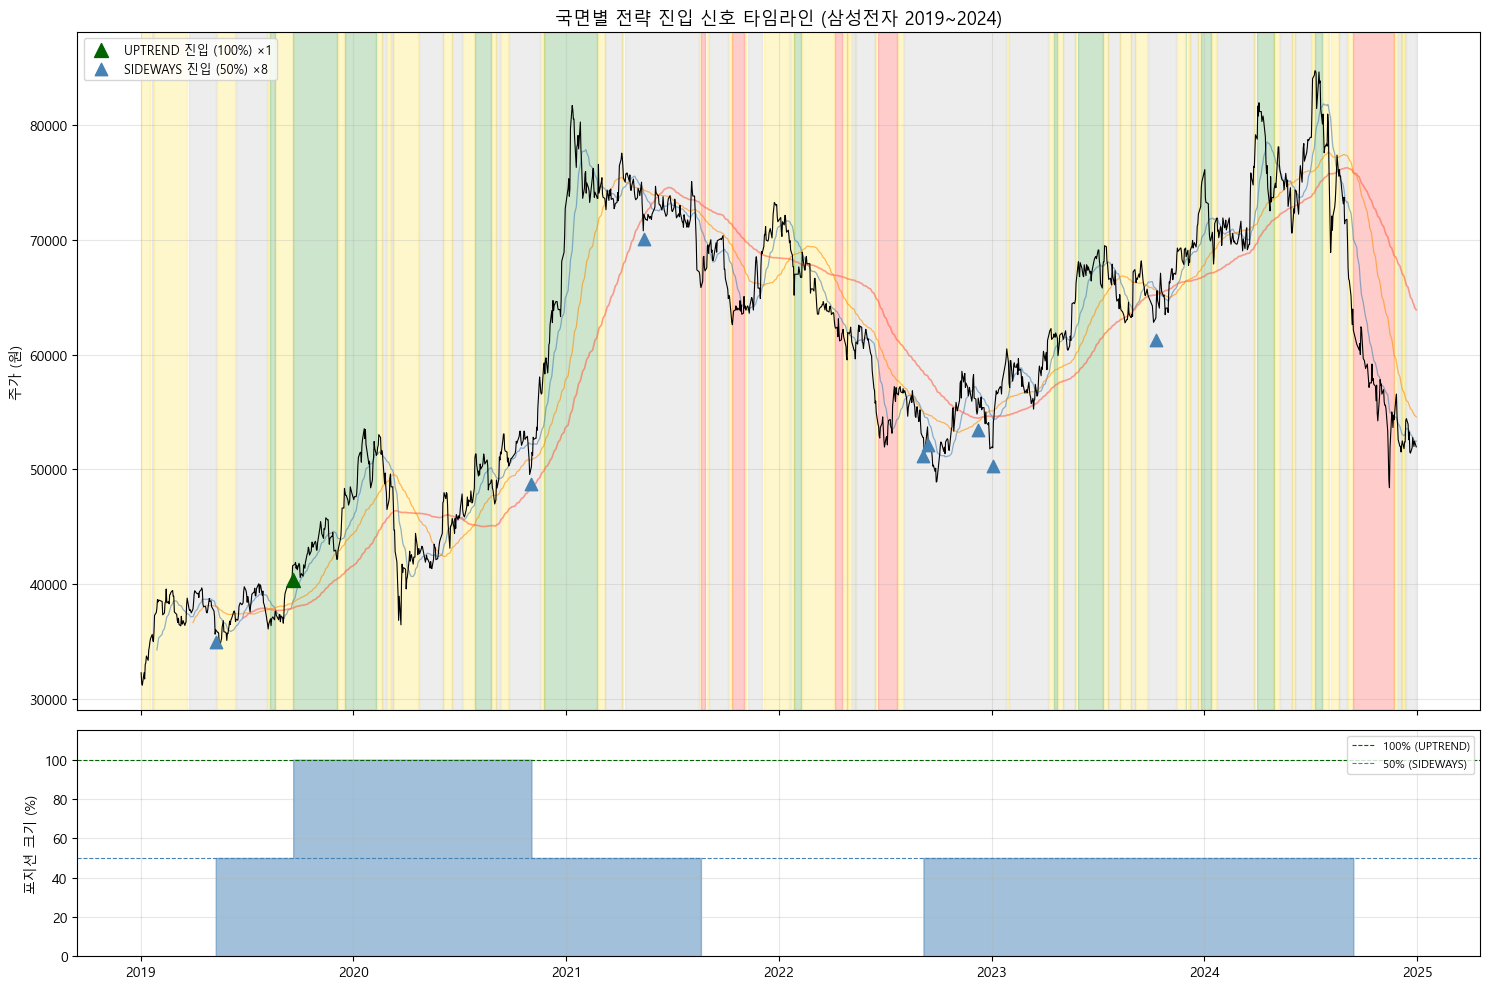

In [7]:
# ── 신호 타임라인 시각화 ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# 상단: 주가 + 국면 배경 + 진입 신호 마커
ymin, ymax = close.min() * 0.93, close.max() * 1.04
for name, (color, alpha) in REGIME_COLORS.items():
    ax1.fill_between(close.index, ymin, ymax,
                     where=(regime == name), color=color, alpha=alpha)

ax1.plot(close, color='black',      linewidth=0.8, zorder=5)
ax1.plot(ma20,  color='steelblue',  linewidth=0.9, alpha=0.6)
ax1.plot(ma60,  color='darkorange', linewidth=0.9, alpha=0.6)
ax1.plot(ma120, color='tomato',     linewidth=1.2, alpha=0.6)

ax1.scatter(close.index[gc_entries], close[gc_entries] * 0.97,
            marker='^', color='darkgreen', s=100, zorder=10,
            label=f'UPTREND 진입 (100%) ×{gc_entries.sum()}')
ax1.scatter(close.index[bb_entries], close[bb_entries] * 0.97,
            marker='^', color='steelblue', s=80, zorder=10,
            label=f'SIDEWAYS 진입 (50%) ×{bb_entries.sum()}')

ax1.set_title('국면별 전략 진입 신호 타임라인 (삼성전자 2019~2024)', fontsize=13)
ax1.set_ylabel('주가 (원)')
ax1.set_ylim(ymin, ymax)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 하단: 포지션 크기
size_filled = size_series.ffill().fillna(0)
ax2.fill_between(close.index, 0, size_filled * 100,
                 color='steelblue', alpha=0.5, step='post')
ax2.axhline(100, color='darkgreen', linewidth=0.8, linestyle='--', label='100% (UPTREND)')
ax2.axhline(50,  color='steelblue', linewidth=0.8, linestyle='--', label='50% (SIDEWAYS)')
ax2.set_ylabel('포지션 크기 (%)')
ax2.set_ylim(0, 115)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5단계 · 전략 비교 백테스트

### 비교 대상

| 전략 | 설명 |
|------|------|
| Buy & Hold | 기준선 |
| 골든크로스 단독 | 국면 필터 없음 |
| 볼린저 밴드 단독 | 국면 필터 없음 |
| 국면 스위처 (균등 비중) | 국면 필터 적용, 모든 진입 동일 비중 |
| **국면 스위처 + 포지션 크기** | 국면 필터 + UPTREND 100% / SIDEWAYS 50% |

In [8]:
FEES     = 0.0015   # 한국 주식 수수료 0.15%
SLIPPAGE = 0.001    # 슬리피지 0.10%

def make_pf_signals(entries, exits):
    return vbt.Portfolio.from_signals(
        close, entries, exits,
        fees=FEES, slippage=SLIPPAGE, freq='D'
    )

# ── 개별 전략 (국면 필터 없음) ────────────────────────────────────────────────
from vbt_backtest.strategies.base import golden_cross, bollinger_band

gc_e, gc_x = golden_cross.make_signals(close)
bb_e, bb_x = bollinger_band.make_signals(close)

# ── Buy & Hold ────────────────────────────────────────────────────────────────
bh_e = pd.Series(False, index=close.index); bh_e.iloc[0] = True
bh_x = pd.Series(False, index=close.index); bh_x.iloc[-1] = True

pf_bh  = make_pf_signals(bh_e, bh_x)
pf_gc  = make_pf_signals(gc_e, gc_x)
pf_bb  = make_pf_signals(bb_e, bb_x)

# ── 국면 스위처 (균등 비중) ───────────────────────────────────────────────────
pf_switcher = make_pf_signals(entries, exits)

# ── 국면 스위처 + 포지션 크기 조절 (모듈 run_backtest 활용) ──────────────────
pf_regime = run_backtest(close, high, low, fees=FEES, slippage=SLIPPAGE)

print(f'백테스트 완료 — 수수료: {FEES:.2%} / 슬리피지: {SLIPPAGE:.2%}')

백테스트 완료 — 수수료: 0.15% / 슬리피지: 0.10%


In [9]:
# ── 성과 비교 테이블 ──────────────────────────────────────────────────────────
strategies = {
    'Buy & Hold':               pf_bh,
    '골든크로스 단독':             pf_gc,
    '볼린저밴드 단독':             pf_bb,
    '국면 스위처 (균등 비중)':      pf_switcher,
    '★ 국면 스위처 + 포지션 크기':  pf_regime,
}

rows = []
for name, pf in strategies.items():
    try:
        trades = pf.trades.count()
    except Exception:
        trades = '-'
    rows.append({
        '전략':          name,
        '총 수익률':      f'{pf.total_return():.2%}',
        '연평균(CAGR)':  f'{pf.annualized_return():.2%}',
        '샤프비율':      f'{pf.sharpe_ratio():.2f}',
        '최대낙폭(MDD)': f'{pf.max_drawdown():.2%}',
        '거래횟수':      trades,
    })

df_result = pd.DataFrame(rows).set_index('전략')
print(f'=== 전략 성과 비교 (삼성전자 2019~2024 / 수수료 {FEES:.2%} / 슬리피지 {SLIPPAGE:.2%}) ===')
print(df_result.to_string())

=== 전략 성과 비교 (삼성전자 2019~2024 / 수수료 0.15% / 슬리피지 0.10%) ===
                    총 수익률 연평균(CAGR)  샤프비율 최대낙폭(MDD)  거래횟수
전략                                                       
Buy & Hold         60.11%    12.35%  0.53   -42.85%     1
골든크로스 단독            8.92%     2.14%  0.21   -44.42%    14
볼린저밴드 단독           24.34%     5.54%  0.35   -37.43%    16
국면 스위처 (균등 비중)     18.43%     4.27%  0.50   -10.93%     7
★ 국면 스위처 + 포지션 크기  64.04%    13.03%  0.71   -31.89%     7


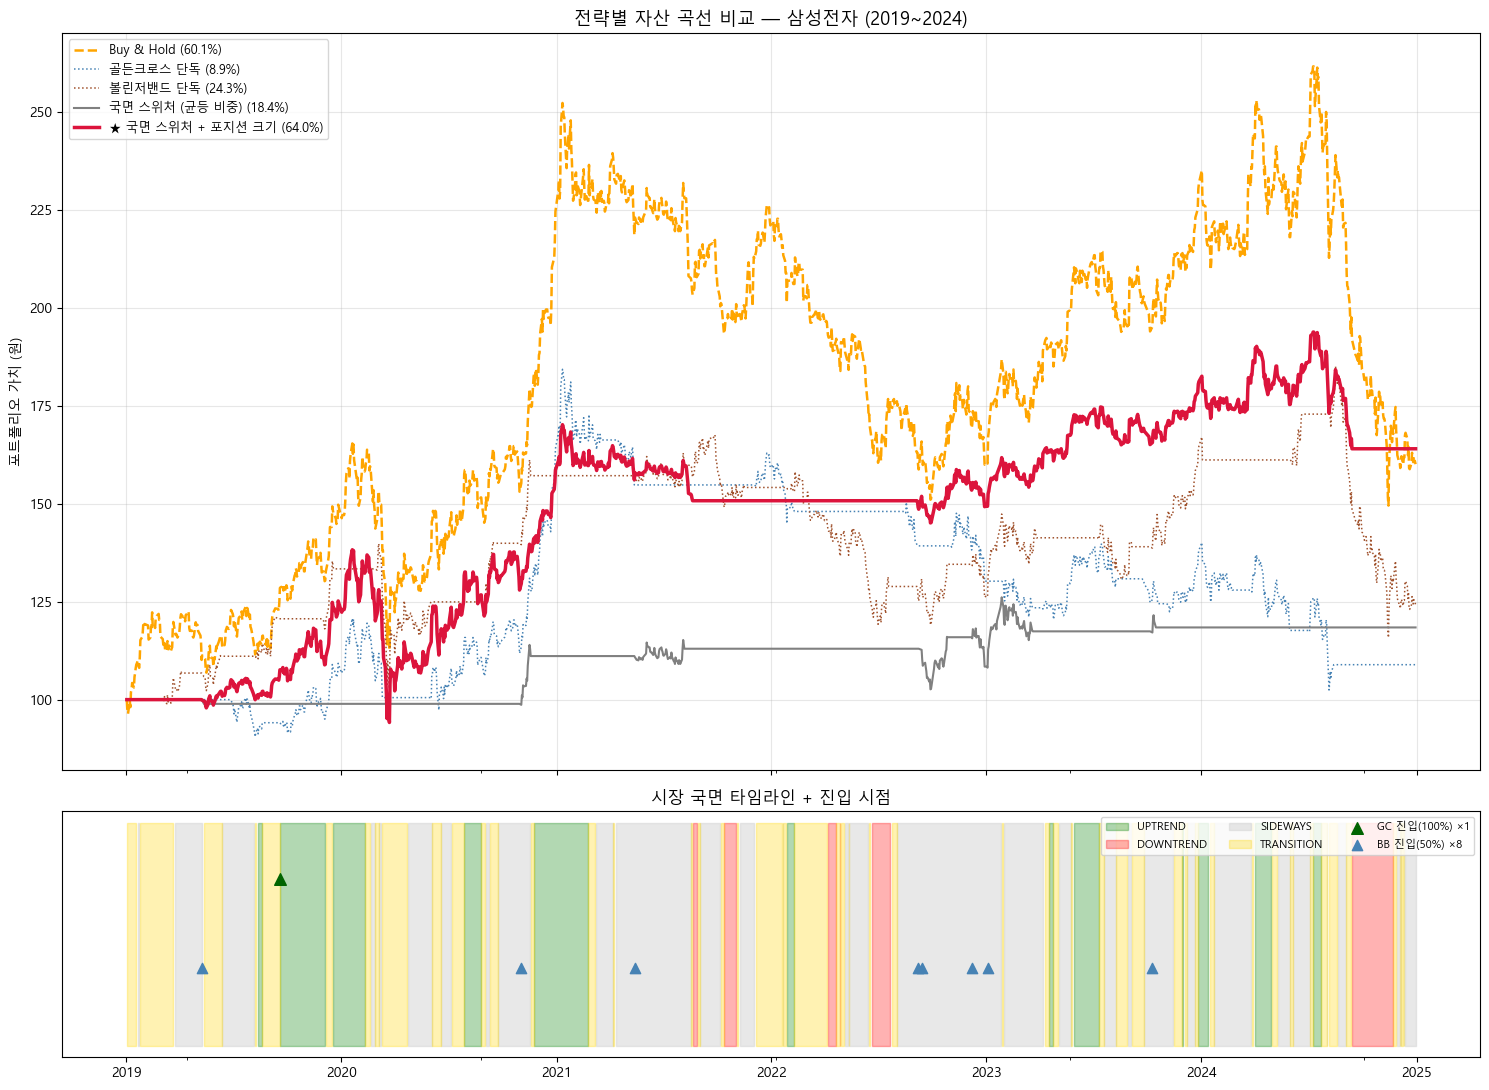

In [10]:
# ── 자산 곡선 + 국면 타임라인 통합 차트 ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 11),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

style_map = {
    'Buy & Hold':               ('orange',     '--', 1.8),
    '골든크로스 단독':             ('steelblue',  ':',  1.1),
    '볼린저밴드 단독':             ('sienna',     ':',  1.1),
    '국면 스위처 (균등 비중)':      ('gray',       '-',  1.5),
    '★ 국면 스위처 + 포지션 크기':  ('crimson',    '-',  2.5),
}

for name, pf in strategies.items():
    color, ls, lw = style_map[name]
    ret = pf.total_return()
    pf.value().plot(ax=ax1, label=f'{name} ({ret:.1%})',
                    color=color, linestyle=ls, linewidth=lw)

ax1.set_title('전략별 자산 곡선 비교 — 삼성전자 (2019~2024)', fontsize=13)
ax1.set_ylabel('포트폴리오 가치 (원)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 하단: 국면 타임라인 + 진입 신호
for name, (color, alpha) in REGIME_COLORS.items():
    ax2.fill_between(close.index, 0, 1,
                     where=(regime == name), color=color, alpha=alpha + 0.1,
                     label=name)

ax2.scatter(close.index[gc_entries], [0.75] * gc_entries.sum(),
            marker='^', color='darkgreen', s=70, zorder=5, label=f'GC 진입(100%) ×{gc_entries.sum()}')
ax2.scatter(close.index[bb_entries], [0.35] * bb_entries.sum(),
            marker='^', color='steelblue', s=55, zorder=5, label=f'BB 진입(50%) ×{bb_entries.sum()}')

ax2.set_title('시장 국면 타임라인 + 진입 시점')
ax2.set_yticks([])
ax2.legend(loc='upper right', fontsize=8, ncol=3)
ax2.grid(False)

plt.tight_layout()
plt.show()

---
## 6단계 · 국면별 수익률 심층 분석

각 국면에서 실제로 얼마나 수익이 났는지 분석합니다.  
이를 통해 전략이 어느 구간에서 효과적인지 파악하고 파라미터 개선 방향을 찾습니다.

=== 국면별 일간 수익률 통계 ===
국면                 평균     표준편차     양봉%     거래일
----------------------------------------------------
UPTREND        0.071%   1.657%   47.5%     257
SIDEWAYS       0.035%   1.471%   47.1%     686
TRANSITION     0.076%   1.841%   49.1%     430
DOWNTREND     -0.072%   1.980%   41.6%     101


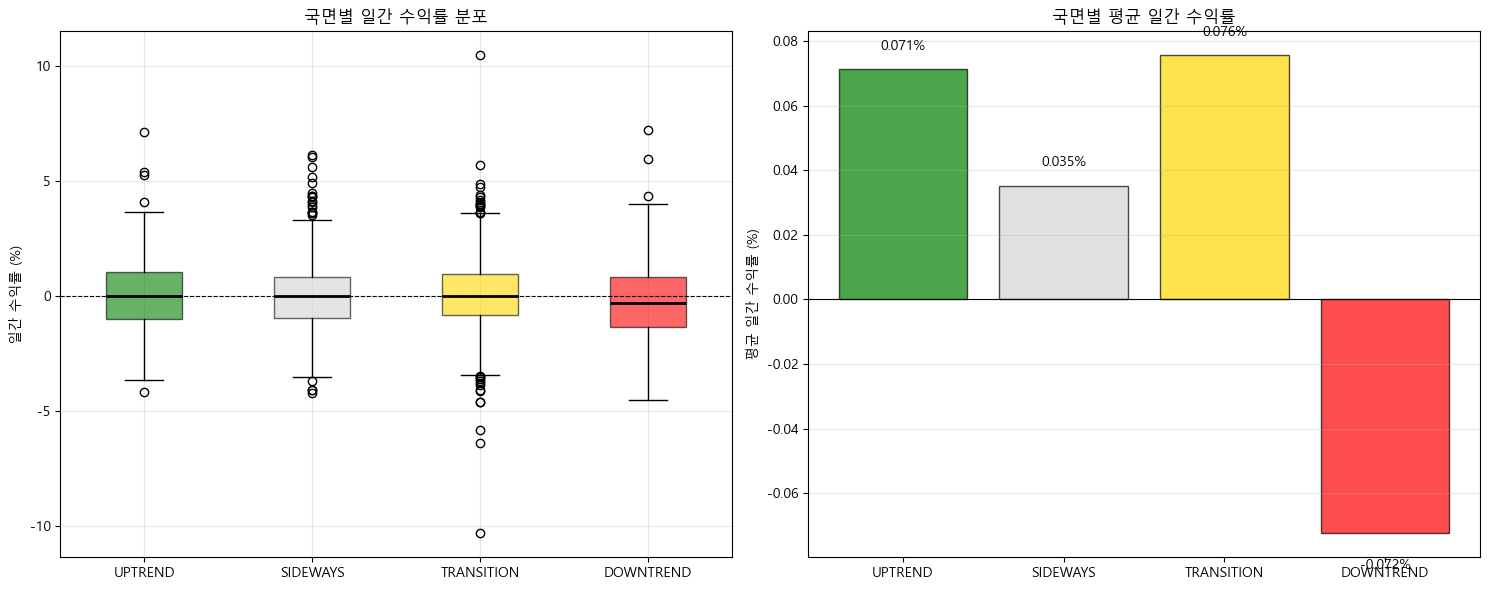

In [11]:
# ── 국면별 주가 수익률 분포 ───────────────────────────────────────────────────
daily_ret = close.pct_change()

regime_order      = ['UPTREND', 'SIDEWAYS', 'TRANSITION', 'DOWNTREND']
regime_colors_list = ['green',  'lightgray', 'gold',       'red']

print('=== 국면별 일간 수익률 통계 ===')
print(f'{"국면":12s}  {"평균":>7s}  {"표준편차":>7s}  {"양봉%":>6s}  {"거래일":>6s}')
print('-' * 52)
for r in regime_order:
    mask  = regime == r
    r_ret = daily_ret[mask].dropna()
    if len(r_ret) == 0:
        continue
    print(f'{r:12s}  {r_ret.mean():>7.3%}  {r_ret.std():>7.3%}  '
          f'{(r_ret > 0).mean():>6.1%}  {len(r_ret):>6d}')

# ── 국면별 수익률 박스플롯 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

data_by_regime = [daily_ret[regime == r].dropna() * 100 for r in regime_order]
bp = axes[0].boxplot(data_by_regime, patch_artist=True,
                     labels=regime_order, notch=False,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], regime_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('국면별 일간 수익률 분포')
axes[0].set_ylabel('일간 수익률 (%)')
axes[0].grid(True, alpha=0.3)

means = [daily_ret[regime == r].dropna().mean() * 100 for r in regime_order]
bars  = axes[1].bar(regime_order, means, color=regime_colors_list, alpha=0.7, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + (0.005 if val >= 0 else -0.008),
                 f'{val:.3f}%', ha='center',
                 va='bottom' if val >= 0 else 'top', fontsize=10)
axes[1].set_title('국면별 평균 일간 수익률')
axes[1].set_ylabel('평균 일간 수익률 (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

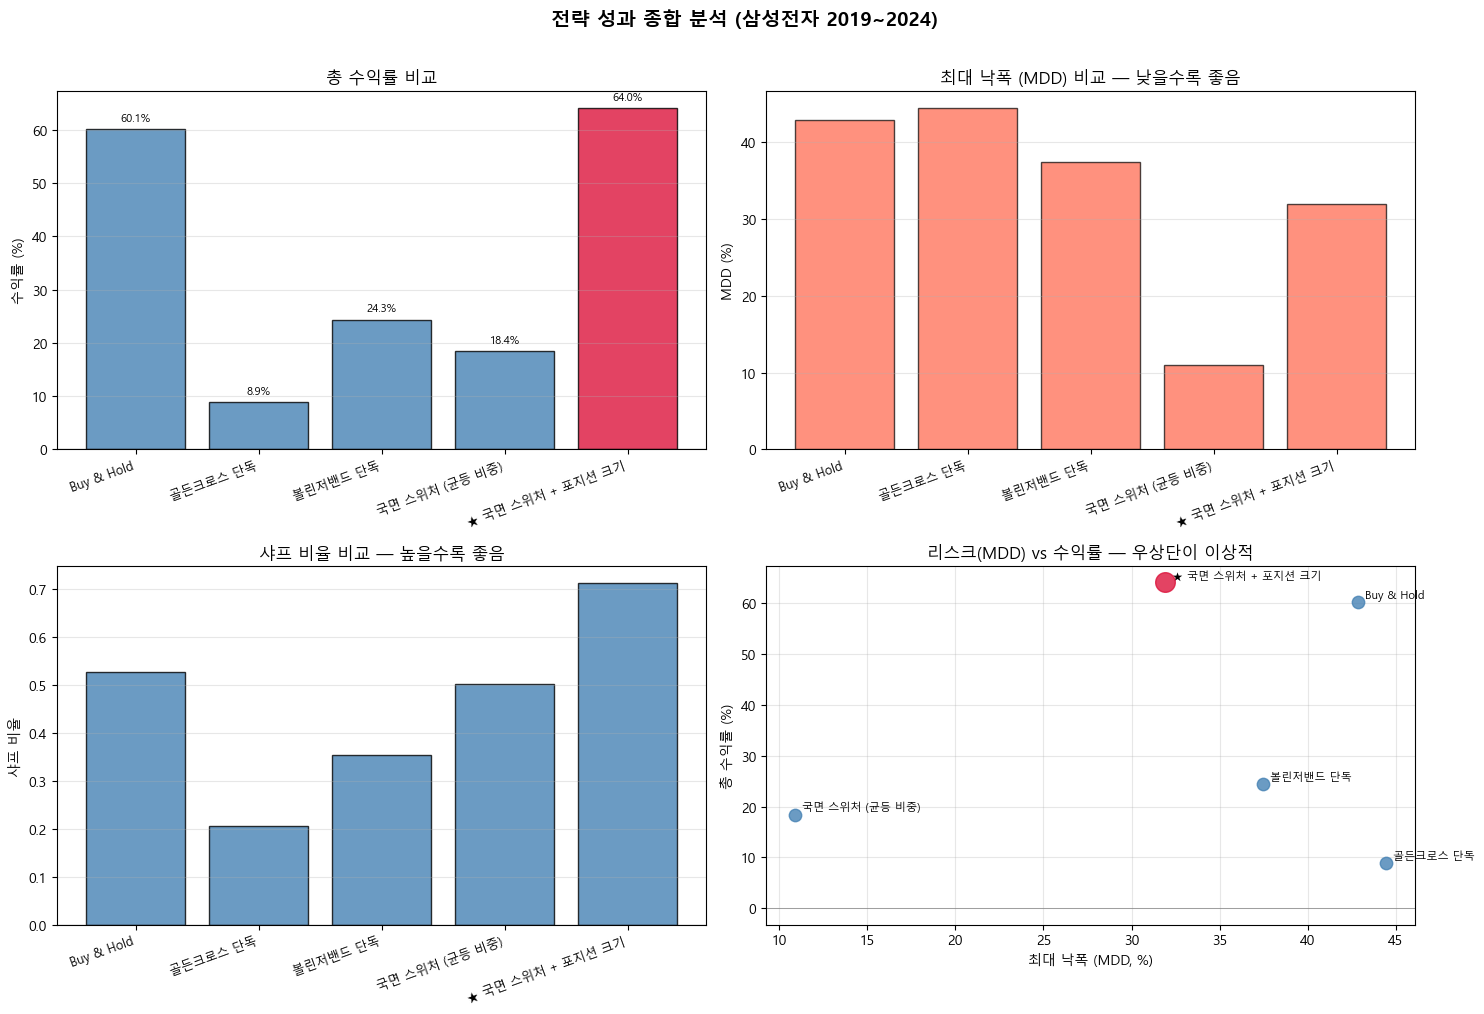

In [12]:
# ── 전략 성과 종합 분석 차트 ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

names   = list(strategies.keys())
returns = [pf.total_return() * 100 for pf in strategies.values()]
mdds    = [abs(pf.max_drawdown()) * 100 for pf in strategies.values()]
sharpes = [pf.sharpe_ratio() for pf in strategies.values()]
colors  = ['crimson' if '★' in n else 'steelblue' for n in names]

# 1) 총 수익률
bars = axes[0, 0].bar(range(len(names)), returns, color=colors, alpha=0.8, edgecolor='black')
axes[0, 0].set_xticks(range(len(names)))
axes[0, 0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0, 0].set_title('총 수익률 비교')
axes[0, 0].set_ylabel('수익률 (%)')
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, returns):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    val + (1 if val >= 0 else -3),
                    f'{val:.1f}%', ha='center',
                    va='bottom' if val >= 0 else 'top', fontsize=8)

# 2) MDD
axes[0, 1].bar(range(len(names)), mdds, color='tomato', alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(len(names)))
axes[0, 1].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0, 1].set_title('최대 낙폭 (MDD) 비교 — 낮을수록 좋음')
axes[0, 1].set_ylabel('MDD (%)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3) 샤프비율
c3 = ['steelblue' if v >= 0 else 'red' for v in sharpes]
axes[1, 0].bar(range(len(names)), sharpes, color=c3, alpha=0.8, edgecolor='black')
axes[1, 0].set_xticks(range(len(names)))
axes[1, 0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[1, 0].set_title('샤프 비율 비교 — 높을수록 좋음')
axes[1, 0].set_ylabel('샤프 비율')
axes[1, 0].axhline(0, color='black', linewidth=0.8)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4) 리스크-수익 산점도
for name, pf in strategies.items():
    color = 'crimson' if '★' in name else 'steelblue'
    size  = 200 if '★' in name else 80
    axes[1, 1].scatter(abs(pf.max_drawdown()) * 100,
                       pf.total_return() * 100,
                       color=color, s=size, zorder=5, alpha=0.8)
    axes[1, 1].annotate(name,
                        (abs(pf.max_drawdown()) * 100, pf.total_return() * 100),
                        fontsize=8, xytext=(5, 3), textcoords='offset points')

axes[1, 1].set_xlabel('최대 낙폭 (MDD, %)')
axes[1, 1].set_ylabel('총 수익률 (%)')
axes[1, 1].set_title('리스크(MDD) vs 수익률 — 우상단이 이상적')
axes[1, 1].axhline(0, color='gray', linewidth=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('전략 성과 종합 분석 (삼성전자 2019~2024)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 7단계 · 월별 수익률 히트맵 (국면 스위처)

월별 수익률을 연도×월 히트맵으로 표현하면 **어느 시기에 손실이 집중됐는지** 파악할 수 있습니다.

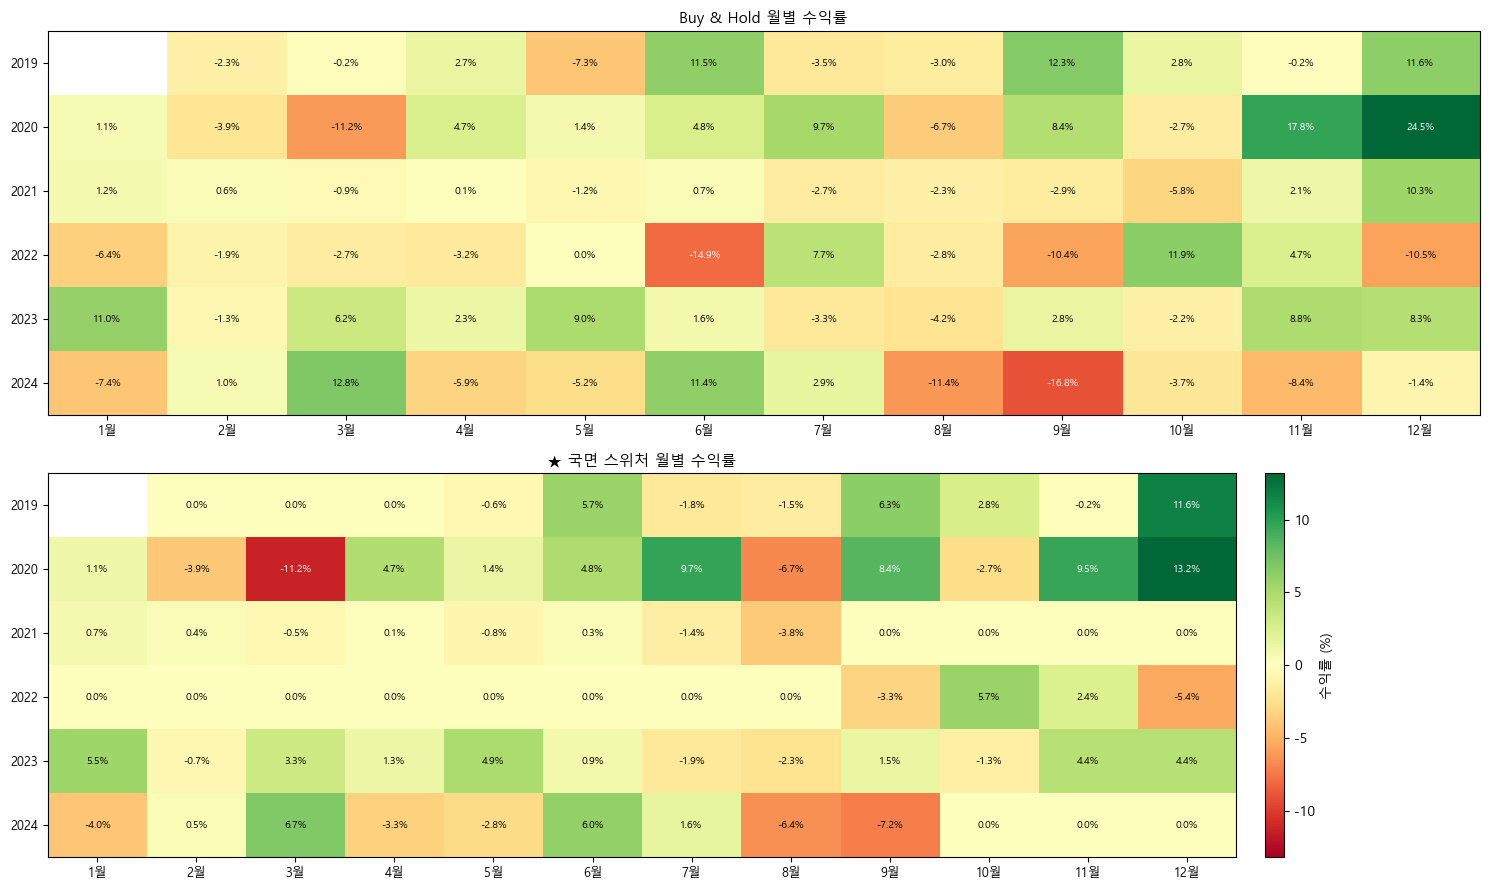

In [13]:
# ── 월별 수익률 히트맵 ────────────────────────────────────────────────────────
def monthly_heatmap(pf, title, ax):
    """포트폴리오 월별 수익률 히트맵 그리기"""
    val = pf.value()
    monthly = val.resample('M').last()
    mret = monthly.pct_change().dropna()

    pivot = pd.DataFrame({
        'year':  mret.index.year,
        'month': mret.index.month,
        'ret':   mret.values,
    }).pivot(index='year', columns='month', values='ret') * 100

    pivot.columns = ['1월','2월','3월','4월','5월','6월',
                     '7월','8월','9월','10월','11월','12월']

    import matplotlib.cm as cm
    vmax = max(abs(pivot.values[~np.isnan(pivot.values)]).max(), 1)
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                   vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(12))
    ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=11)

    for i in range(len(pivot.index)):
        for j in range(12):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}%', ha='center', va='center',
                        fontsize=7.5, color='black' if abs(v) < vmax * 0.6 else 'white')

    return im

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

im1 = monthly_heatmap(pf_bh,     'Buy & Hold 월별 수익률',  axes[0])
im2 = monthly_heatmap(pf_regime, '★ 국면 스위처 월별 수익률', axes[1])

plt.colorbar(im2, ax=axes[1], label='수익률 (%)', pad=0.02)
plt.tight_layout()
plt.show()

---
## 8단계 · 파라미터 감도 분석

ADX 임계값(threshold)을 변화시키면 국면 분류가 달라지고 성과가 바뀝니다.  
어떤 ADX 기준이 가장 좋은 샤프비율을 내는지 빠르게 확인합니다.

=== ADX 임계값별 성과 (국면 스위처 + 포지션 크기) ===
          총 수익률     연평균  샤프비율      MDD  거래횟수
ADX 임계값                                     
15       45.99%   9.82%  0.59  -31.89%     7
18       45.99%   9.82%  0.59  -31.89%     7
20       45.99%   9.82%  0.59  -31.89%     7
22       41.37%   8.94%  0.58  -31.89%     7
25       64.04%  13.03%  0.71  -31.89%     7
28       48.38%  10.26%  0.73  -19.08%     7
30       49.17%  10.40%  0.74  -19.08%     7
35       37.98%   8.29%  0.59  -22.25%     7


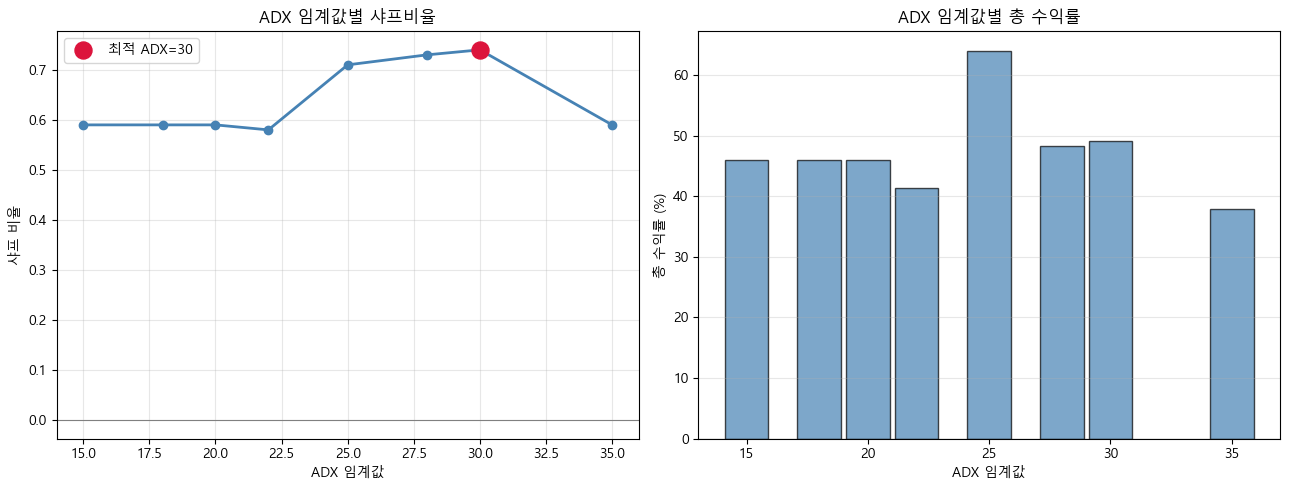


최적 ADX 임계값: 30 (샤프비율 0.74)


In [15]:
# ── ADX 임계값별 성과 스캔 ────────────────────────────────────────────────────
adx_thresholds = [15, 18, 20, 22, 25, 28, 30, 35]

scan_rows = []
for thresh in adx_thresholds:
    # 모듈의 make_signals에 adx_threshold 파라미터 전달
    _, _, sz, _ = make_signals(close, high, low, adx_threshold=thresh)

    pf_t = vbt.Portfolio.from_orders(
        close, size=sz, size_type='targetpercent',
        fees=FEES, slippage=SLIPPAGE, freq='D',
    )
    scan_rows.append({
        'ADX 임계값': thresh,
        '총 수익률':  f'{pf_t.total_return():.2%}',
        '연평균':     f'{pf_t.annualized_return():.2%}',
        '샤프비율':   round(pf_t.sharpe_ratio(), 2),
        'MDD':       f'{pf_t.max_drawdown():.2%}',
        '거래횟수':   pf_t.trades.count(),
    })

df_scan = pd.DataFrame(scan_rows).set_index('ADX 임계값')
print('=== ADX 임계값별 성과 (국면 스위처 + 포지션 크기) ===')
print(df_scan.to_string())

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sharpe_vals = df_scan['샤프비율'].values
ax1.plot(adx_thresholds, sharpe_vals, 'o-', color='steelblue', linewidth=2)
ax1.axhline(0, color='gray', linewidth=0.8)
best_idx = int(np.argmax(sharpe_vals))
ax1.scatter([adx_thresholds[best_idx]], [sharpe_vals[best_idx]],
            color='crimson', s=150, zorder=5, label=f'최적 ADX={adx_thresholds[best_idx]}')
ax1.set_title('ADX 임계값별 샤프비율')
ax1.set_xlabel('ADX 임계값')
ax1.set_ylabel('샤프 비율')
ax1.legend()
ax1.grid(True, alpha=0.3)

rets = [float(df_scan.loc[t, '총 수익률'].rstrip('%')) for t in adx_thresholds]
ax2.bar(adx_thresholds, rets, color='steelblue', alpha=0.7, width=1.8, edgecolor='black')
ax2.set_title('ADX 임계값별 총 수익률')
ax2.set_xlabel('ADX 임계값')
ax2.set_ylabel('총 수익률 (%)')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print(f'\n최적 ADX 임계값: {adx_thresholds[best_idx]} (샤프비율 {sharpe_vals[best_idx]:.2f})')

---
## 정리

### 4국면 전략 설계 요약

| 국면 | 판별 조건 | 매수 | 매도 |
|------|----------|------|------|
| UPTREND | MA20>MA60>MA120 AND ADX>25 | 골든크로스 → 100% 진입 | 데드크로스 또는 DOWNTREND 전환 시 청산 |
| DOWNTREND | MA20<MA60<MA120 AND ADX>25 | 없음 | 전량 청산 (size=0) |
| SIDEWAYS | ADX < 20 | 볼린저밴드 하단 → 50% 진입 | BB 상단 또는 DOWNTREND 전환 시 청산 |
| TRANSITION | 위 3가지 미해당 | 없음 | 별도 청산 없음 (NaN 유지, 기존 포지션 유지) |

### TRANSITION 설계 원칙

```
TRANSITION → 신규 진입 차단, 기존 포지션 유지
  └ 이유: MA120 후행성으로 인한 불필요한 조기 청산 방지
  └ 효과: 포지션이 전략 신호(데드크로스·DOWNTREND 전환)로만 청산됨
```

### 포지션 크기 조절

```
UPTREND   (확신)   → 100% 풀 포지션  ← 수익 극대화
SIDEWAYS  (불확실) →  50% 절반 포지션 ← 손실 제한
DOWNTREND (위험)   →   0% 전량 청산  ← 손실 방어
TRANSITION(모호)   →  NaN 유지       ← 기존 포지션 그대로
```

### 기관·퀀트가 이 설계를 쓰는 이유

```
1. 단순하다  — 2개 지표(MA + ADX)로 모든 국면 대응
2. 해석 가능하다 — "왜 진입했는가"를 명확히 설명 가능
3. 강건하다  — 종목/자산군이 달라도 동일 로직 적용
4. 리스크가 명확하다 — DOWNTREND에서 완전 이탈, MDD 제어
```

### 한계 및 다음 단계
- **후행성**: MA120 기반이라 국면 변화 감지에 수주 지연
- **단일 종목**: 다중 종목 포트폴리오로 확장 시 더 강건해짐
- **과최적화**: ADX 감도 스캔 결과를 그대로 사용하면 과적합 위험 → `08_워크포워드_최적화.ipynb`에서 검증